# DTW vs. Few-Shot CNN — Results Analysis

Reads the CSVs produced by `compare_dtw_cnn.py` (`results_trials.csv`,
`results_summary.csv`, `results_utterances.csv`) and builds the plots and
tables you'd want for comparing DTW against the few-shot CNN across the
`n_classes x samples_per_class` grid.

Just set `RESULTS_DIR` below to point at your output folder and run all
cells. Everything else adapts to whatever locales / grid values / trial
counts are actually present in the CSVs — nothing here is hardcoded to a
specific grid.


In [15]:
# ---- Config ----
RESULTS_DIR = './results_dtw_vs_cnn'   # folder containing results_trials.csv etc.
SAVE_FIGURES = False                     # if True, also saves each plot as a .png into RESULTS_DIR/figures

# Optional: if you know what grid you ran, fill these in to get a
# "missing combinations" report (useful after a --resume'd / interrupted run).
# Leave any of them as None to skip that check.
EXPECTED_N_CLASSES = None          # e.g. [2, 3, 5, 8]
EXPECTED_SAMPLES_PER_CLASS = None  # e.g. [1, 2, 3, 7, 10, 17, 27]
EXPECTED_TRIALS = None             # e.g. 5


In [16]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.facecolor"] = "white"

results_dir = Path(RESULTS_DIR)
fig_dir = results_dir / "figures"
if SAVE_FIGURES:
    fig_dir.mkdir(parents=True, exist_ok=True)


def maybe_save(fig, name):
    if SAVE_FIGURES:
        fig.savefig(fig_dir / f"{name}.png", dpi=150, bbox_inches="tight")


## Load data

In [17]:
trials_path = results_dir / "results_trials.csv"
summary_path = results_dir / "results_summary.csv"
utter_path = results_dir / "results_utterances.csv"

if not trials_path.exists():
    raise FileNotFoundError(
        f"Couldn't find {trials_path}. Set RESULTS_DIR to the --output-dir you "
        f"passed to compare_dtw_cnn.py."
    )

trials = pd.read_csv(trials_path)

# Numeric columns can come in as object dtype if some rows left them blank
# (e.g. dtw rows have no train_time_sec) -- coerce explicitly.
numeric_cols = [
    "n_classes_requested", "n_classes_actual", "samples_per_class", "trial", "seed",
    "num_enrollment_total", "num_test_samples", "correct", "accuracy", "word_error_rate",
    "eval_time_sec", "train_time_sec", "epochs_run", "best_train_acc",
]
for c in numeric_cols:
    if c in trials.columns:
        trials[c] = pd.to_numeric(trials[c], errors="coerce")

print(f"Loaded {len(trials):,} trial rows")
print(f"Locales: {sorted(trials['locale'].unique())}")
print(f"Methods: {sorted(trials['method'].unique())}")
print(f"n_classes values: {sorted(trials['n_classes_requested'].unique())}")
print(f"samples_per_class values: {sorted(trials['samples_per_class'].unique())}")

utterances = None
if utter_path.exists():
    utterances = pd.read_csv(utter_path)
    print(f"\nLoaded {len(utterances):,} utterance rows")
else:
    print("\nNo results_utterances.csv found -- confusion-pair analysis near the "
          "end of this notebook will be skipped (rerun compare_dtw_cnn.py without "
          "--no-detailed to get it).")

trials.head()


Loaded 7,240 trial rows
Locales: ['ab', 'ar', 'ca', 'cs', 'cv', 'cy', 'de', 'en', 'eo', 'es', 'eu', 'fr', 'fy-NL', 'id', 'ja', 'ka', 'kab', 'ky', 'lg', 'nl', 'or', 'pl', 'pt', 'ru', 'rw', 'sv-SE', 'ta', 'th', 'tr', 'tt', 'zh-CN', 'zh-HK', 'zh-TW']
Methods: ['cnn', 'dtw']
n_classes values: [np.int64(2), np.int64(3), np.int64(5), np.int64(8)]
samples_per_class values: [np.int64(1), np.int64(2), np.int64(3), np.int64(7), np.int64(10), np.int64(17), np.int64(27)]

Loaded 551,838 utterance rows


,locale,method,n_classes_requested,n_classes_actual,samples_per_class,trial,seed,num_enrollment_total,num_test_samples,correct,accuracy,word_error_rate,eval_time_sec,train_time_sec,epochs_run,best_train_acc,dtw_feature,dtw_distance,dtw_classify,dtw_sample_rate,dtw_num_coeffs
0,ab,dtw,2,2,1,0,1245,2,20,16,0.8000,0.2000,2.48,NaN,NaN,NaN,mfcc,euclidean,best_match,16000.0,13.0
1,ab,cnn,2,2,1,0,1245,2,20,9,0.4500,0.5500,NaN,3.57,22.0,1.0,NaN,NaN,NaN,NaN,NaN
2,ab,dtw,2,2,1,1,101248,2,21,13,0.6190,0.3810,0.32,NaN,NaN,NaN,mfcc,euclidean,best_match,16000.0,13.0
3,ab,cnn,2,2,1,1,101248,2,21,13,0.6190,0.3810,NaN,0.16,13.0,1.0,NaN,NaN,NaN,NaN,NaN
4,ab,dtw,2,2,1,2,201251,2,17,7,0.4118,0.5882,0.29,NaN,NaN,NaN,mfcc,euclidean,best_match,16000.0,13.0


## Coverage overview

How much of the grid actually has results, and (if you filled in
`EXPECTED_*` above) what's still missing.


In [18]:
coverage = (
    trials.groupby(["method", "n_classes_requested", "samples_per_class"])
    .size()
    .rename("num_rows")
    .reset_index()
)
n_locales = trials["locale"].nunique()
print(f"Locales with any results: {n_locales}")
print(f"Grid points x methods with at least one trial: {len(coverage)}")
print(f"Trial-count range across grid points: "
      f"{coverage['num_rows'].min()}–{coverage['num_rows'].max()} "
      f"(expect roughly n_locales x trials per point if every locale had enough words)")

total_eval_time = trials["eval_time_sec"].sum(skipna=True)
total_train_time = trials["train_time_sec"].sum(skipna=True)
print(f"\nTotal DTW eval time logged:   {total_eval_time/3600:.1f} h")
print(f"Total CNN train+eval time logged: {total_train_time/3600:.1f} h")

if EXPECTED_N_CLASSES and EXPECTED_SAMPLES_PER_CLASS and EXPECTED_TRIALS:
    expected = set()
    for locale in trials["locale"].unique():
        for m in trials["method"].unique():
            for nc in EXPECTED_N_CLASSES:
                for spc in EXPECTED_SAMPLES_PER_CLASS:
                    for t in range(EXPECTED_TRIALS):
                        expected.add((locale, m, nc, spc, t))
    have = set(
        trials[["locale", "method", "n_classes_requested", "samples_per_class", "trial"]]
        .itertuples(index=False, name=None)
    )
    missing = expected - have
    print(f"\nExpected combinations: {len(expected):,} | present: {len(have):,} | "
          f"missing: {len(missing):,} ({100*len(missing)/len(expected):.1f}%)")
    if missing:
        missing_df = pd.DataFrame(
            sorted(missing), columns=["locale", "method", "n_classes", "samples_per_class", "trial"]
        )
        print("\nMissing by (n_classes, samples_per_class) -- top offenders:")
        display(
            missing_df.groupby(["n_classes", "samples_per_class"]).size()
            .rename("missing_count").reset_index()
            .sort_values("missing_count", ascending=False)
            .head(15)
        )
else:
    print("\n(Set EXPECTED_N_CLASSES / EXPECTED_SAMPLES_PER_CLASS / EXPECTED_TRIALS "
          "above to see a missing-combinations report.)")

coverage_pivot = coverage.pivot_table(
    index="n_classes_requested", columns="samples_per_class", values="num_rows", aggfunc="sum"
)
print("\nRows present per (n_classes x samples_per_class), summed over locales/trials/both methods:")
coverage_pivot


Locales with any results: 33
Grid points x methods with at least one trial: 56
Trial-count range across grid points: 100–165 (expect roughly n_locales x trials per point if every locale had enough words)

Total DTW eval time logged:   1.1 h
Total CNN train+eval time logged: 17.0 h

(Set EXPECTED_N_CLASSES / EXPECTED_SAMPLES_PER_CLASS / EXPECTED_TRIALS above to see a missing-combinations report.)

Rows present per (n_classes x samples_per_class), summed over locales/trials/both methods:


samples_per_class,1,2,3,7,10,17,27
n_classes_requested,,,,,,,
2,330,300,280,260,250,220,210
3,320,300,280,250,250,220,210
5,320,290,270,250,250,210,210
8,320,270,270,250,240,210,200


## Overall accuracy: DTW vs. CNN

         mean  median     std  count
method                              
cnn     0.383  0.3563  0.1991   3620
dtw     0.405  0.3833  0.1975   3620


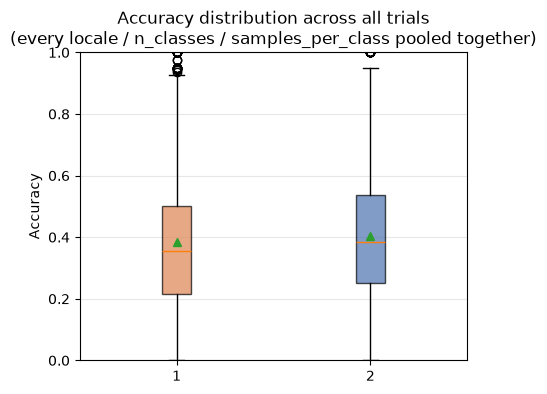

In [30]:
overall = trials.groupby("method")["accuracy"].agg(["mean", "median", "std", "count"])
print(overall.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
methods = sorted(trials["method"].unique())
data = [trials.loc[trials["method"] == m, "accuracy"].dropna() for m in methods]
bp = ax.boxplot(data, label=[m.upper() for m in methods], patch_artist=True, showmeans=True)
colors = {"dtw": "#4C72B0", "cnn": "#DD8452"}
for patch, m in zip(bp["boxes"], methods):
    patch.set_facecolor(colors.get(m, "#999999"))
    patch.set_alpha(0.7)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy distribution across all trials\n(every locale / n_classes / samples_per_class pooled together)")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
maybe_save(fig, "overall_accuracy_boxplot")
plt.show()


## Accuracy vs. samples_per_class, faceted by n_classes

Mean accuracy (± 1 std across locales x trials) at each grid point, one
panel per `n_classes`. This is the main "how many recordings do I need"
chart.


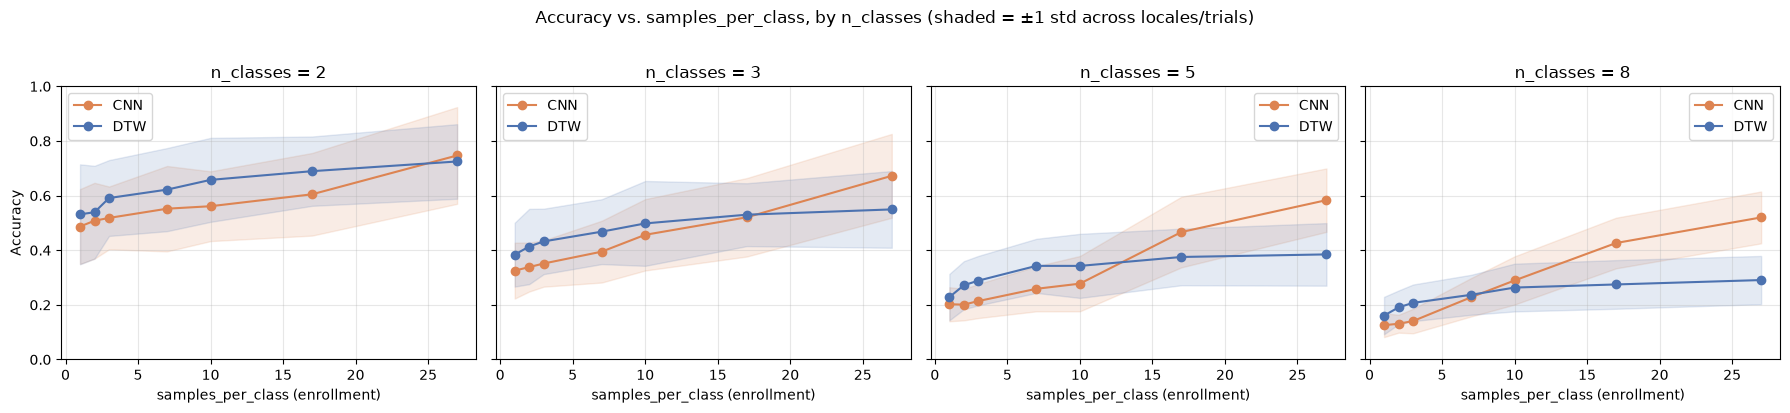

In [20]:
grid_stats = (
    trials.groupby(["method", "n_classes_requested", "samples_per_class"])["accuracy"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

n_classes_values = sorted(trials["n_classes_requested"].unique())
ncols = min(len(n_classes_values), 4)
nrows = int(np.ceil(len(n_classes_values) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), sharey=True, squeeze=False)
axes = axes.flatten()

for i, nc in enumerate(n_classes_values):
    ax = axes[i]
    sub = grid_stats[grid_stats["n_classes_requested"] == nc]
    for m in sorted(sub["method"].unique()):
        s = sub[sub["method"] == m].sort_values("samples_per_class")
        ax.plot(s["samples_per_class"], s["mean"], marker="o", label=m.upper(),
                color=colors.get(m, None))
        ax.fill_between(
            s["samples_per_class"],
            (s["mean"] - s["std"].fillna(0)).clip(lower=0),
            (s["mean"] + s["std"].fillna(0)).clip(upper=1),
            alpha=0.15, color=colors.get(m, None),
        )
    ax.set_title(f"n_classes = {nc}")
    ax.set_xlabel("samples_per_class (enrollment)")
    if i % ncols == 0:
        ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

for j in range(len(n_classes_values), len(axes)):
    axes[j].axis("off")

fig.suptitle("Accuracy vs. samples_per_class, by n_classes (shaded = ±1 std across locales/trials)", y=1.02)
fig.tight_layout()
maybe_save(fig, "accuracy_vs_samples_per_class_by_n_classes")
plt.show()


## Grid heatmaps: mean accuracy, and CNN − DTW advantage

Averaged across all locales and trials at each grid point.


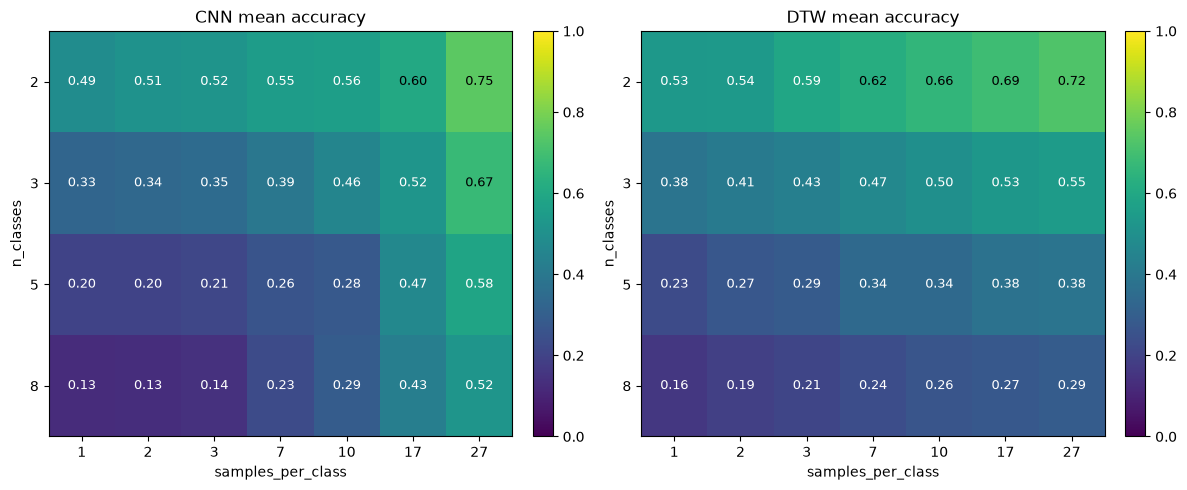

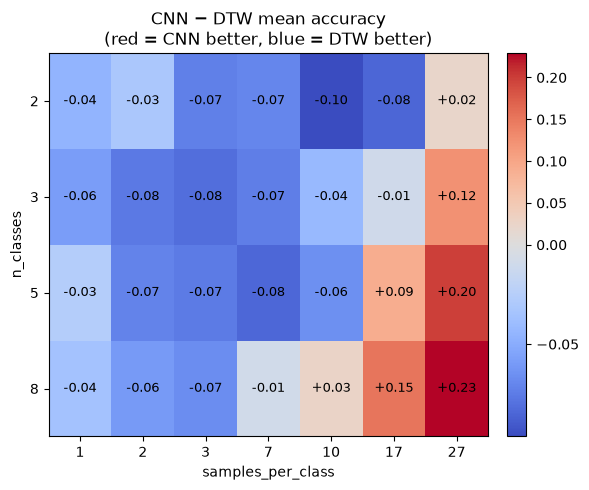

In [21]:
def pivot_mean(method):
    return (
        trials[trials["method"] == method]
        .pivot_table(index="n_classes_requested", columns="samples_per_class",
                     values="accuracy", aggfunc="mean")
    )


methods_present = sorted(trials["method"].unique())
pivots = {m: pivot_mean(m) for m in methods_present}

fig, axes = plt.subplots(1, len(methods_present), figsize=(6 * len(methods_present), 5))
if len(methods_present) == 1:
    axes = [axes]

for ax, m in zip(axes, methods_present):
    p = pivots[m]
    im = ax.imshow(p.values, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(p.columns))); ax.set_xticklabels(p.columns)
    ax.set_yticks(range(len(p.index))); ax.set_yticklabels(p.index)
    ax.set_xlabel("samples_per_class"); ax.set_ylabel("n_classes")
    ax.set_title(f"{m.upper()} mean accuracy")
    for r in range(p.shape[0]):
        for c in range(p.shape[1]):
            v = p.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < 0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
maybe_save(fig, "accuracy_heatmaps_by_method")
plt.show()

# Difference heatmap (only meaningful if both methods present)
if "dtw" in pivots and "cnn" in pivots:
    diff = (pivots["cnn"] - pivots["dtw"]).reindex(
        index=sorted(set(pivots["cnn"].index) | set(pivots["dtw"].index)),
        columns=sorted(set(pivots["cnn"].columns) | set(pivots["dtw"].columns)),
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    norm = TwoSlopeNorm(vmin=min(-0.01, np.nanmin(diff.values)), vcenter=0,
                         vmax=max(0.01, np.nanmax(diff.values)))
    im = ax.imshow(diff.values, cmap="coolwarm", norm=norm, aspect="auto")
    ax.set_xticks(range(len(diff.columns))); ax.set_xticklabels(diff.columns)
    ax.set_yticks(range(len(diff.index))); ax.set_yticklabels(diff.index)
    ax.set_xlabel("samples_per_class"); ax.set_ylabel("n_classes")
    ax.set_title("CNN − DTW mean accuracy\n(red = CNN better, blue = DTW better)")
    for r in range(diff.shape[0]):
        for c in range(diff.shape[1]):
            v = diff.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:+.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    maybe_save(fig, "accuracy_diff_heatmap")
    plt.show()


## Trial-level win rate

Rather than comparing averages, this pairs up DTW and CNN on the *same*
(locale, n_classes, samples_per_class, trial) -- the whole point of using
matched splits -- and asks how often CNN actually beat DTW head-to-head.


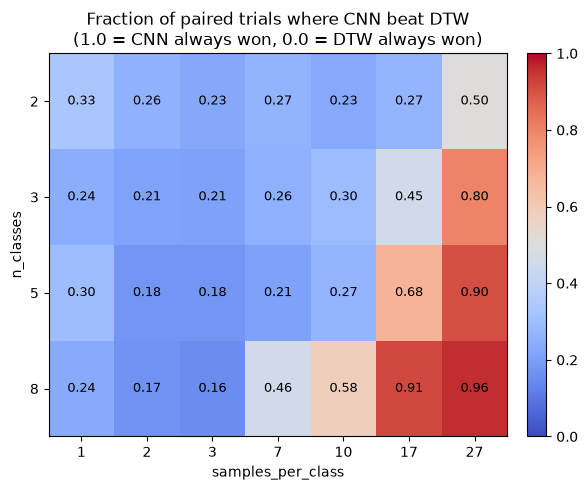

In [22]:
key_cols = ["locale", "n_classes_requested", "samples_per_class", "trial"]
if {"dtw", "cnn"} <= set(trials["method"].unique()):
    wide = trials.pivot_table(index=key_cols, columns="method", values="accuracy")
    wide = wide.dropna(subset=["dtw", "cnn"])
    wide["cnn_wins"] = wide["cnn"] > wide["dtw"]
    wide["tie"] = wide["cnn"] == wide["dtw"]

    win_rate = (
        wide.reset_index()
        .groupby(["n_classes_requested", "samples_per_class"])
        .agg(cnn_win_rate=("cnn_wins", "mean"), n_paired_trials=("cnn_wins", "size"))
        .reset_index()
    )
    win_pivot = win_rate.pivot_table(index="n_classes_requested", columns="samples_per_class", values="cnn_win_rate")

    fig, ax = plt.subplots(figsize=(6, 5))
    norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
    im = ax.imshow(win_pivot.values, cmap="coolwarm", norm=norm, aspect="auto")
    ax.set_xticks(range(len(win_pivot.columns))); ax.set_xticklabels(win_pivot.columns)
    ax.set_yticks(range(len(win_pivot.index))); ax.set_yticklabels(win_pivot.index)
    ax.set_xlabel("samples_per_class"); ax.set_ylabel("n_classes")
    ax.set_title("Fraction of paired trials where CNN beat DTW\n(1.0 = CNN always won, 0.0 = DTW always won)")
    for r in range(win_pivot.shape[0]):
        for c in range(win_pivot.shape[1]):
            v = win_pivot.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    maybe_save(fig, "cnn_win_rate_heatmap")
    plt.show()
else:
    print("Need both 'dtw' and 'cnn' rows to compute a paired win rate.")


## Crossover point

For each `n_classes`, the smallest `samples_per_class` at which CNN's mean
accuracy caught up to (or passed) DTW's.


In [23]:
rows = []
for nc in n_classes_values:
    sub = grid_stats[grid_stats["n_classes_requested"] == nc]
    dtw_s = sub[sub["method"] == "dtw"].set_index("samples_per_class")["mean"]
    cnn_s = sub[sub["method"] == "cnn"].set_index("samples_per_class")["mean"]
    common = sorted(set(dtw_s.index) & set(cnn_s.index))
    crossover = None
    for spc in common:
        if cnn_s[spc] >= dtw_s[spc]:
            crossover = spc
            break
    rows.append({
        "n_classes": nc,
        "crossover_samples_per_class": crossover if crossover is not None else "CNN never caught up in tested range",
        "dtw_acc_at_max_spc": round(dtw_s[max(common)], 4) if common else None,
        "cnn_acc_at_max_spc": round(cnn_s[max(common)], 4) if common else None,
    })

pd.DataFrame(rows)


,n_classes,crossover_samples_per_class,dtw_acc_at_max_spc,cnn_acc_at_max_spc
0,2,27,0.7249,0.7469
1,3,27,0.5495,0.6724
2,5,17,0.3848,0.5834
3,8,10,0.2908,0.5201


## Compute cost

DTW time is pure inference (enroll + classify); CNN time is training +
inference, so these aren't apples-to-apples -- but this tells you what
each comparison is actually costing you.


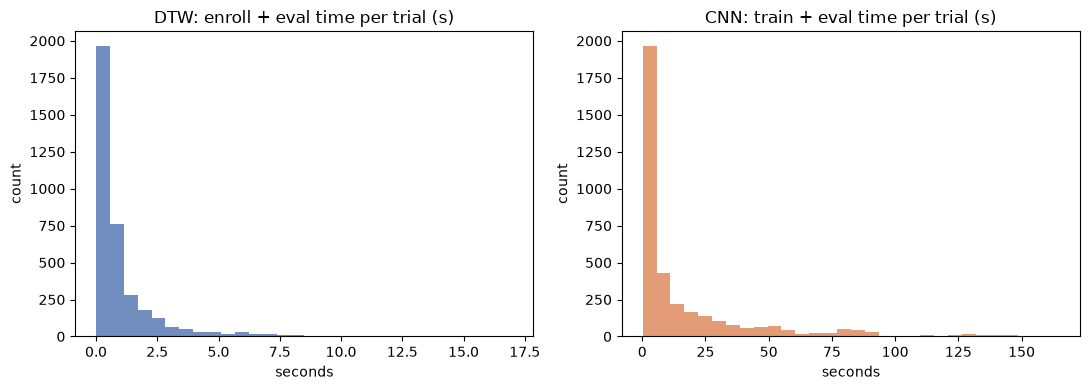

DTW median time/trial: 0.51s   (mean 1.06s)
CNN median time/trial: 4.51s   (mean 16.87s)

Mean epochs run before early stopping, by samples_per_class:
samples_per_class
1     18.9
2     20.6
3     23.9
7     32.2
10    35.9
17    43.6
27    51.3
Name: epochs_run, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

dtw_times = trials.loc[trials["method"] == "dtw", "eval_time_sec"].dropna()
cnn_times = trials.loc[trials["method"] == "cnn", "train_time_sec"].dropna()

axes[0].hist(dtw_times, bins=30, color=colors.get("dtw"), alpha=0.8)
axes[0].set_title("DTW: enroll + eval time per trial (s)")
axes[0].set_xlabel("seconds"); axes[0].set_ylabel("count")

axes[1].hist(cnn_times, bins=30, color=colors.get("cnn"), alpha=0.8)
axes[1].set_title("CNN: train + eval time per trial (s)")
axes[1].set_xlabel("seconds"); axes[1].set_ylabel("count")

fig.tight_layout()
maybe_save(fig, "compute_time_histograms")
plt.show()

print(f"DTW median time/trial: {dtw_times.median():.2f}s   (mean {dtw_times.mean():.2f}s)")
print(f"CNN median time/trial: {cnn_times.median():.2f}s   (mean {cnn_times.mean():.2f}s)")

if "epochs_run" in trials.columns:
    epochs_by_spc = (
        trials[trials["method"] == "cnn"]
        .groupby("samples_per_class")["epochs_run"]
        .mean()
    )
    print("\nMean epochs run before early stopping, by samples_per_class:")
    print(epochs_by_spc.round(1))


## Per-locale breakdown

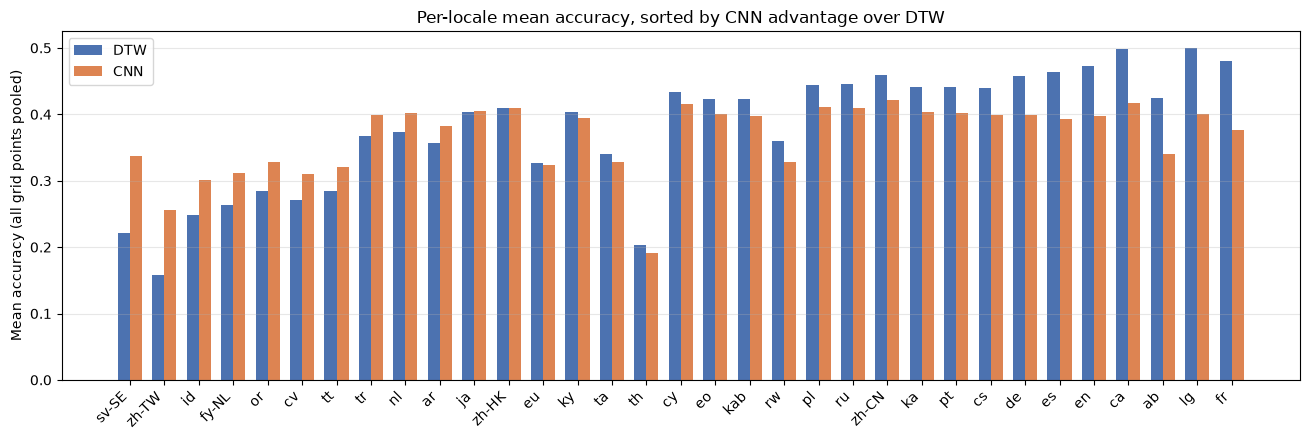

method,cnn,dtw,cnn_minus_dtw
locale,,,
sv-SE,0.3376,0.2216,0.1160
zh-TW,0.2558,0.1575,0.0983
id,0.3015,0.2477,0.0538
fy-NL,0.3109,0.2630,0.0480
or,0.3287,0.2848,0.0440
cv,0.3102,0.2715,0.0387
tt,0.3203,0.2853,0.0350
tr,0.3989,0.3671,0.0319
nl,0.4022,0.3731,0.0291


In [25]:
per_locale = (
    trials.groupby(["locale", "method"])["accuracy"].mean().unstack("method")
)
if {"dtw", "cnn"} <= set(per_locale.columns):
    per_locale["cnn_minus_dtw"] = per_locale["cnn"] - per_locale["dtw"]
    per_locale = per_locale.sort_values("cnn_minus_dtw", ascending=False)

    fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(per_locale)), 4.5))
    x = np.arange(len(per_locale))
    width = 0.35
    ax.bar(x - width / 2, per_locale["dtw"], width, label="DTW", color=colors.get("dtw"))
    ax.bar(x + width / 2, per_locale["cnn"], width, label="CNN", color=colors.get("cnn"))
    ax.set_xticks(x); ax.set_xticklabels(per_locale.index, rotation=45, ha="right")
    ax.set_ylabel("Mean accuracy (all grid points pooled)")
    ax.set_title("Per-locale mean accuracy, sorted by CNN advantage over DTW")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    maybe_save(fig, "per_locale_accuracy")
    plt.show()

per_locale.round(4)


## Confusion analysis

Most commonly confused word pairs, per method (requires
`results_utterances.csv` -- rerun without `--no-detailed` if this is
empty).


In [26]:
if utterances is not None:
    mistakes = utterances[utterances["correct"].astype(str).str.lower().isin(["false", "0"])]
    for m in sorted(mistakes["method"].unique()):
        sub = mistakes[mistakes["method"] == m]
        top_confusions = (
            sub.groupby(["true_word", "predicted_word"]).size()
            .rename("count").reset_index()
            .sort_values("count", ascending=False)
            .head(15)
        )
        print(f"\nTop confusions for {m.upper()}:")
        display(top_confusions)
else:
    print("No utterance-level data loaded -- skipping.")



Top confusions for CNN:


,true_word,predicted_word,count
2459,zero,firefox,273
3968,一,七,246
4043,五,四,241
619,firefox,zero,231
4008,九,七,230
783,hey,firefox,220
3981,七,一,216
558,firefox,hey,206
542,firefox,dos,203
4107,四,三,190



Top confusions for DTW:


,true_word,predicted_word,count
559,firefox,hey,257
4119,四,三,223
4141,零,一,211
4016,三,四,206
321,dos,tres,201
4007,三,七,199
3994,七,三,199
3992,一,零,198
3993,七,一,197
1110,naw,dau,193


In [27]:
if utterances is not None:
    for group_col in ["gender", "age"]:
        if group_col not in utterances.columns:
            continue
        sub = utterances[~utterances[group_col].isin(["unknown", "", None])]
        if sub.empty:
            print(f"No non-'unknown' {group_col} data available.")
            continue
        acc_by_group = (
            sub.assign(correct=sub["correct"].astype(str).str.lower().isin(["true", "1"]))
            .groupby([group_col, "method"])["correct"].mean().unstack("method")
        )
        print(f"\nAccuracy by {group_col}:")
        display(acc_by_group.round(4))



Accuracy by gender:


method,cnn,dtw
gender,,
female,0.3269,0.3457
male,0.3312,0.3415
other,0.3472,0.3889



Accuracy by age:


method,cnn,dtw
age,,
eighties,0.4012,0.2901
fifties,0.3399,0.3614
fourties,0.3345,0.3415
nineties,0.4545,0.6364
seventies,0.3632,0.3491
sixties,0.3153,0.3474
teens,0.3247,0.3480
thirties,0.3322,0.3533
twenties,0.3303,0.3368


## Key metrics summary

In [28]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
for m in methods_present:
    sub = trials[trials["method"] == m]
    print(f"\n{m.upper()}")
    print(f"  Trials run:        {len(sub):,}")
    print(f"  Mean accuracy:     {sub['accuracy'].mean():.4f}")
    print(f"  Median accuracy:   {sub['accuracy'].median():.4f}")
    best = sub.loc[sub['accuracy'].idxmax()]
    print(f"  Best single trial: {best['accuracy']:.4f}  "
          f"(locale={best['locale']}, n_classes={best['n_classes_requested']}, "
          f"samples_per_class={best['samples_per_class']})")

if {"dtw", "cnn"} <= set(methods_present):
    overall_gap = trials[trials.method=='cnn']['accuracy'].mean() - trials[trials.method=='dtw']['accuracy'].mean()
    print(f"\nOverall mean accuracy gap (CNN - DTW), pooled across the whole grid: {overall_gap:+.4f}")
    print("(Pooling across a grid this different in difficulty is a blunt number --")
    print(" the faceted plots above are the more honest comparison.)")


SUMMARY

CNN
  Trials run:        3,620
  Mean accuracy:     0.3830
  Median accuracy:   0.3563
  Best single trial: 1.0000  (locale=ab, n_classes=2, samples_per_class=7)

DTW
  Trials run:        3,620
  Mean accuracy:     0.4050
  Median accuracy:   0.3833
  Best single trial: 1.0000  (locale=ab, n_classes=3, samples_per_class=10)

Overall mean accuracy gap (CNN - DTW), pooled across the whole grid: -0.0220
(Pooling across a grid this different in difficulty is a blunt number --
 the faceted plots above are the more honest comparison.)
